# Stack Overflow Survey Job Satisfaction Model

This notebook takes the cleaned respondent parquet from `src/comp_clean.py` and walks through the satisfaction modeling path directly in the notebook. The goal is to surface the harmonization, feature decisions, preprocessing, feature audit, and model comparisons that led to the canonical implementation in `src/satisfaction_modeling.py` rather than hiding them behind a single imported helper.


In [5]:
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd()
while ROOT.parent != ROOT and not (ROOT / 'src').exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings('ignore', category=FutureWarning)

In [6]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from catboost import CatBoostClassifier, Pool
from IPython.display import display
from scipy.linalg import qr
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    recall_score,
)
from statsmodels.miscmodels.ordinal_model import OrderedModel

from src import comp_clean

## Notebook Setup

1. Load `clean_core.parquet` and validate the fields needed for job satisfaction
2. Build the harmonized 5-point target in the notebook and audit year coverage
3. Audit broad and candidate feature coverage by year before locking the main spec
4. Freeze the canonical years, feature set, and time-based split
5. Define the local helpers for preprocessing, baselines, feature audit, and candidate models
6. Compare the baseline, ordered model, LightGBM, and CatBoost on the same split
7. Check compensation only as a same-sample sensitivity rather than part of the main model
8. Inspect harmonization sensitivity, untouched 2025 diagnostics, and rolling-origin stability


In [7]:
RANDOM_STATE = 42
ORDERED_MAX_ROWS = 50_000

SAT_TARGET = 'job_sat_std'
SAT_BINARY = 'sat_binary'
SAT_INSTRUMENT = 'job_sat_instrument'
SAT_LABELS = [1, 2, 3, 4, 5]
SAT_BINARY_THRESHOLD = 4
SAT_CANONICAL_YEARS = [2015, 2016, 2017, 2018, 2019, 2020, 2024, 2025]
SAT_TRAIN_YEARS = [2015, 2016, 2017, 2018, 2019, 2020]
SAT_VALID_YEAR = 2024
SAT_TEST_YEAR = 2025
SAT_NUMERIC_SCHEMES = {
    'default': [1, 4, 6, 8],
    'alt_equal_width': [2, 4, 6, 8]
}
SAT_INSTRUMENTS = {
    2015: 'text_5pt',
    2016: 'text_5pt',
    2017: 'numeric_11pt',
    2018: 'text_7pt',
    2019: 'text_5pt',
    2020: 'text_5pt',
    2024: 'numeric_11pt',
    2025: 'numeric_11pt'
}
SAT_MAP = {
    "I hate my job": 1,
    "I'm somewhat dissatisfied with my job": 2,
    "I'm neither satisfied nor dissatisfied with my job": 3,
    "I'm neither satisfied nor dissatisfied": 3,
    "I'm somewhat satisfied with my job": 4,
    "I love my job": 5,
    "I don't have a job": np.nan,
    "Other (please specify)": np.nan,
    'Extremely dissatisfied': 1,
    'Moderately dissatisfied': 2,
    'Slightly dissatisfied': 2,
    'Neither satisfied nor dissatisfied': 3,
    'Slightly satisfied': 4,
    'Moderately satisfied': 4,
    'Extremely satisfied': 5,
    'Very dissatisfied': 1,
    'Very satisfied': 5
}
DEFAULT_LGB_PARAMS = {
    'objective': 'multiclass',
    'metric': 'multi_logloss',
    'num_class': len(SAT_LABELS),
    'n_estimators': 400,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 50,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.0,
    'reg_lambda': 0.0,
    'class_weight': 'balanced',
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbosity': -1
}
DEFAULT_CATBOOST_PARAMS = {
    'loss_function': 'MultiClass',
    'eval_metric': 'MultiClass',
    'iterations': 500,
    'learning_rate': 0.05,
    'depth': 8,
    'l2_leaf_reg': 5.0,
    'random_seed': RANDOM_STATE,
    'auto_class_weights': 'Balanced',
    'allow_writing_files': False,
    'verbose': False
}
SAT_BASELINE_GROUP_SETS = [
    ['country_clean'],
    ['region'],
    []
]


## Load Finalized Clean Core

Double checks to make sure the `clean_core.parquet` file exists and that the columns needed for satisfaction modeling are present and formatted as expected.


In [8]:
CLEAN_PATH = ROOT / 'data' / 'derived' / 'clean_core.parquet'

clean_core = comp_clean.load_clean_core(CLEAN_PATH)

required_cols = {
    'survey_year',
    'job_sat',
    'is_professional',
    'employment_primary',
    'is_full_time_employed',
    'is_part_time_employed',
    'is_independent',
    'region',
    'country_clean',
    'age_group',
    'education_clean',
    'org_size_clean',
    'remote_group',
    'years_code_clean',
    'language_count',
    'database_count',
    'platform_count',
    'role_family_count',
    'log_comp_real_2025'
}
missing_cols = sorted(required_cols - set(clean_core.columns))
assert not missing_cols, f'Missing required columns: {missing_cols}'

string_cols = clean_core.select_dtypes(include='string').columns
clean_core[string_cols] = clean_core[string_cols].fillna(pd.NA)

print('clean_core shape:', clean_core.shape)
display(clean_core[['survey_year', 'job_sat', 'country_clean', 'employment_primary']].head())


clean_core shape: (746226, 105)


,survey_year,job_sat,country_clean,employment_primary
0,2015,I'm somewhat satisfied with my job,Croatia,Employed full-time
1,2015,I'm neither satisfied nor dissatisfied with my...,France,Employed full-time
2,2015,I'm somewhat satisfied with my job,India,Independent / contract
3,2015,I'm somewhat satisfied with my job,Latvia,Employed full-time
4,2015,I love my job,Norway,Employed full-time


## Notebook Helper Functions And Feature Sets

The functions below keep the full satisfaction path visible inside the notebook. The point is not to be pretty here, the point is to make the target build, feature choices, preprocessing, and modeling decisions explicit before they are mirrored in the pipeline.


In [9]:
def sat_instrument(survey_year):
    return SAT_INSTRUMENTS.get(survey_year, pd.NA)


# Numeric years use a coarse 0-10 -> 1-5 mapping so they can live with the text scales

def numeric_job_sat_to_ordinal(value, scheme='default'):
    if pd.isna(value):
        return np.nan

    cutoffs = SAT_NUMERIC_SCHEMES[scheme]
    try:
        numeric = float(value)
    except (TypeError, ValueError):
        return np.nan

    if numeric <= cutoffs[0]:
        return 1
    if numeric <= cutoffs[1]:
        return 2
    if numeric <= cutoffs[2]:
        return 3
    if numeric <= cutoffs[3]:
        return 4
    return 5


def standardize_job_sat_value(value, survey_year, numeric_scheme='default'):
    if pd.isna(value):
        return np.nan

    instrument = sat_instrument(survey_year)
    if instrument == 'numeric_11pt':
        return numeric_job_sat_to_ordinal(value, scheme=numeric_scheme)

    return SAT_MAP.get(value, np.nan)


def add_job_sat_std(frame, numeric_scheme='default'):
    out = frame.copy()
    out[SAT_INSTRUMENT] = out['survey_year'].map(sat_instrument)
    out[SAT_TARGET] = [
        standardize_job_sat_value(value, year, numeric_scheme=numeric_scheme)
        for value, year in zip(out['job_sat'], out['survey_year'], strict=False)
    ]
    return out


# These age and career-stage features only stay if they survive the audit later on

def add_career_stage_features(frame):
    out = frame.copy()
    age_mid = pd.to_numeric(out.get('age_mid', pd.Series(pd.NA, index=out.index)), errors='coerce')
    years_code = pd.to_numeric(out.get('years_code_clean', pd.Series(pd.NA, index=out.index)), errors='coerce')
    prof_exp = pd.to_numeric(
        out.get('professional_experience_years', pd.Series(pd.NA, index=out.index)),
        errors='coerce'
    )

    out['age_mid'] = age_mid
    out['professional_experience_years'] = prof_exp
    out['career_start_age_est'] = age_mid - prof_exp
    out['coding_start_age_est'] = age_mid - years_code

    ratio = (prof_exp / years_code).where(years_code.ne(0))
    out['pro_to_total_code_ratio'] = pd.Series(ratio, index=out.index).replace([np.inf, -np.inf], np.nan)
    return out


def paid_work_mask(frame):
    flag_cols = ['is_full_time_employed', 'is_part_time_employed', 'is_independent']
    return frame[flag_cols].fillna(False).astype(bool).any(axis=1)


def build_satisfaction_frame(
    clean_frame,
    include_years=None,
    numeric_scheme='default',
    drop_2018=False,
    require_professional=True,
    require_employed=True,
    add_binary_target=True,
    binary_threshold=SAT_BINARY_THRESHOLD
):
    include_years = SAT_CANONICAL_YEARS if include_years is None else include_years
    frame = add_job_sat_std(clean_frame, numeric_scheme=numeric_scheme)
    frame = add_career_stage_features(frame)
    frame = frame.loc[frame['survey_year'].isin(include_years)].copy()
    if drop_2018:
        frame = frame.loc[frame['survey_year'].ne(2018)].copy()
    frame = frame.loc[frame[SAT_TARGET].notna()].copy()

    if require_professional:
        frame = frame.loc[frame['is_professional']].copy()
    if require_employed:
        frame = frame.loc[paid_work_mask(frame)].copy()

    frame[SAT_TARGET] = frame[SAT_TARGET].astype(int)
    frame['survey_year_str'] = frame['survey_year'].astype('string')
    if add_binary_target:
        frame[SAT_BINARY] = frame[SAT_TARGET].ge(binary_threshold).astype(int)

    return frame


def job_sat_year_summary(clean_frame, include_years=None, numeric_scheme='default', drop_2018=False):
    include_years = SAT_CANONICAL_YEARS if include_years is None else include_years
    frame = add_job_sat_std(clean_frame, numeric_scheme=numeric_scheme)
    frame = frame.loc[frame['survey_year'].isin(include_years)].copy()
    if drop_2018:
        frame = frame.loc[frame['survey_year'].ne(2018)].copy()

    employed_mask = paid_work_mask(frame)
    return (
        frame
        .groupby('survey_year')
        .agg(
            rows=('survey_year', 'size'),
            raw_non_null=('job_sat', lambda series: int(series.notna().sum())),
            harmonized_non_null=(SAT_TARGET, lambda series: int(series.notna().sum())),
            employed_prof_non_null=(
                SAT_TARGET,
                lambda series: int(
                    series.loc[
                        frame.loc[series.index, 'is_professional']
                        & employed_mask.loc[series.index]
                    ].notna().sum()
                )
            )
        )
        .reset_index()
    )


In [10]:
def job_sat_distribution_by_year(frame, target_col=SAT_TARGET):
    return (
        frame
        .groupby('survey_year')[target_col]
        .value_counts()
        .unstack(fill_value=0)
        .reindex(columns=SAT_LABELS, fill_value=0)
        .reset_index()
    )


def feature_availability_by_year(frame, columns):
    rows = []
    for year in sorted(frame['survey_year'].unique()):
        sub = frame.loc[frame['survey_year'].eq(year)]
        row = {'survey_year': year, 'rows': len(sub)}
        for col in columns:
            row[col] = round(float(sub[col].notna().mean()), 3) if col in sub.columns else np.nan
        rows.append(row)
    return pd.DataFrame(rows)


def get_role_cols(frame):
    excluded = {'role_family', 'role_family_count'}
    return sorted(col for col in frame.columns if col.startswith('role_') and col not in excluded)


def build_feature_sets(role_cols):
    core_no_comp_cat = [
        'survey_year_str',
        'region',
        'country_clean',
        'age_group',
        'education_clean',
        'employment_primary',
        'org_size_clean',
        'remote_group'
    ]
    core_no_comp_num = [
        'age_mid',
        'years_code_clean',
        'professional_experience_years',
        'career_start_age_est',
        'coding_start_age_est',
        'pro_to_total_code_ratio',
        'language_count',
        'database_count',
        'platform_count',
        'role_family_count'
    ] + role_cols

    core_with_comp_cat = core_no_comp_cat.copy()
    core_with_comp_num = core_no_comp_num + ['log_comp_real_2025']

    ordered_cat = [
        'survey_year_str',
        'region',
        'age_group',
        'education_clean',
        'employment_primary',
        'org_size_clean',
        'remote_group'
    ]
    ordered_num = ['years_code_clean']

    return {
        'core_no_comp_cat': core_no_comp_cat,
        'core_no_comp_num': core_no_comp_num,
        'core_with_comp_cat': core_with_comp_cat,
        'core_with_comp_num': core_with_comp_num,
        'ordered_cat': ordered_cat,
        'ordered_num': ordered_num
    }


sat_df = build_satisfaction_frame(clean_core)
role_cols = get_role_cols(sat_df)
feature_sets = build_feature_sets(role_cols)
core_cat = feature_sets['core_no_comp_cat']
core_num = feature_sets['core_no_comp_num']
core_with_comp_cat = feature_sets['core_with_comp_cat']
core_with_comp_num = feature_sets['core_with_comp_num']
ordered_cat = feature_sets['ordered_cat']
ordered_num = feature_sets['ordered_num']

print('Canonical satisfaction rows:', len(sat_df))
print('Role flags used:', len(role_cols))


Canonical satisfaction rows: 313011
Role flags used: 17


,survey_year,rows,raw_non_null,harmonized_non_null,employed_prof_non_null
0,2015,26086,16174,16004,15509
1,2016,56030,40110,39425,37813
2,2017,51392,40376,40376,39648
3,2018,98855,69276,69276,63347
4,2019,88883,70988,70988,63583
5,2020,64461,45194,45194,40661
6,2024,65437,29126,29126,27029
7,2025,49191,26670,26670,25421


job_sat_std,survey_year,1,2,3,4,5
0,2015,289,1535,1731,6346,5608
1,2016,778,4334,4211,15831,12659
2,2017,813,4286,8311,16681,9557
3,2018,2297,12393,4367,32881,11409
4,2019,4321,9520,7736,21810,20196
5,2020,3341,6368,5150,12543,13259
6,2024,504,2797,5181,13019,5528
7,2025,289,1891,4786,12158,6297


job_sat_std,survey_year,1,2,3,4,5
0,2015,0.019,0.099,0.112,0.409,0.362
1,2016,0.021,0.115,0.111,0.419,0.335
2,2017,0.021,0.108,0.210,0.421,0.241
3,2018,0.036,0.196,0.069,0.519,0.180
4,2019,0.068,0.150,0.122,0.343,0.318
5,2020,0.082,0.157,0.127,0.308,0.326
6,2024,0.019,0.103,0.192,0.482,0.205
7,2025,0.011,0.074,0.188,0.478,0.248


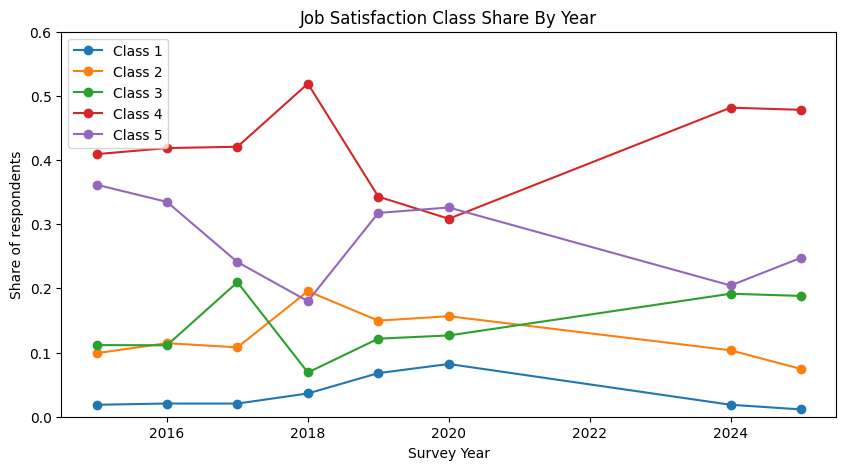

In [11]:
year_summary = job_sat_year_summary(clean_core)
display(year_summary)

class_counts = job_sat_distribution_by_year(sat_df)
class_props = class_counts.copy()
class_cols = [1, 2, 3, 4, 5]
class_props[class_cols] = class_props[class_cols].div(class_props[class_cols].sum(axis=1), axis=0)

display(class_counts)
display(class_props.round(3))

plt.figure(figsize=(10, 5))
for label in class_cols:
    plt.plot(class_props['survey_year'], class_props[label], marker='o', label=f'Class {label}')
plt.title('Job Satisfaction Class Share By Year')
plt.xlabel('Survey Year')
plt.ylabel('Share of respondents')
plt.ylim(0, 0.6)
plt.legend()
plt.show()


## Final Satisfaction Task And Split Choice

The main task should use every year where the target can be defended on the same 5-point scale: `2015-2020, 2024, 2025`. The `2021-2023` waves stay out because there is no directly comparable target in the current cleaned table. Since this is year-indexed repeated cross-sectional survey data, the split also needs to stay year-aware: `2015-2020` train, `2024` validation, `2025` final test. Compensation remains out of the main feature set so the headline model can score the broader employed-professional population, while the promoted age and career-stage features stay in only if they hold up under the final audit.


In [12]:
availability_cols = [
    'region',
    'country_clean',
    'age_group',
    'education_clean',
    'employment_primary',
    'org_size_clean',
    'remote_group',
    'age_mid',
    'years_code_clean',
    'professional_experience_years',
    'career_start_age_est',
    'coding_start_age_est',
    'pro_to_total_code_ratio',
    'language_count',
    'database_count',
    'platform_count',
    'role_family_count',
    'main_branch',
    'student',
    'undergrad_major',
    'industry_clean',
    'ic_or_pm_clean',
    'webframe_count',
    'misc_tech_count',
    'learn_code_count',
    'learn_code_online_count',
    'coding_activities_count',
    'op_sys_prof_count',
    'ai_use',
    'ai_sent',
    'log_comp_real_2025'
]
availability_table = feature_availability_by_year(sat_df, availability_cols)
display(availability_table)

feature_view = pd.DataFrame({
    'core_no_comp_cat': pd.Series(core_cat),
    'core_no_comp_num': pd.Series(core_num),
    'ordered_cat': pd.Series(ordered_cat),
    'ordered_num': pd.Series(ordered_num)
})
display(feature_view)

candidate_pool = pd.DataFrame([
    {'candidate': 'age_mid', 'status': 'Promoted', 'reason': 'Broad support and stable lift'},
    {'candidate': 'professional_experience_years', 'status': 'Promoted', 'reason': 'Broad support and pairs well with age-derived features'},
    {'candidate': 'career_start_age_est', 'status': 'Promoted', 'reason': 'Useful career-stage proxy from age and experience'},
    {'candidate': 'coding_start_age_est', 'status': 'Promoted', 'reason': 'Useful coding-history proxy from age and years coding'},
    {'candidate': 'pro_to_total_code_ratio', 'status': 'Promoted', 'reason': 'Useful experience mix proxy'},
    {'candidate': 'undergrad_major', 'status': 'Side candidate', 'reason': 'Small and mixed lift, not decisive enough to lock in'},
    {'candidate': 'student', 'status': 'Side candidate', 'reason': 'Mixed signal and limited generalization value once employment is modeled'},
    {'candidate': 'main_branch', 'status': 'Side candidate', 'reason': 'Patchy early coverage and unstable rolling-origin behavior'},
    {'candidate': 'industry_clean', 'status': 'Side candidate', 'reason': 'Sparse across the historical train years'},
    {'candidate': 'ic_or_pm_clean', 'status': 'Side candidate', 'reason': 'Later-wave only and not fit for the canonical cross-year spec'},
    {'candidate': 'webframe_count / misc_tech_count', 'status': 'Rejected for main spec', 'reason': 'Later support and unstable cross-year benefit'},
    {'candidate': 'AI and learning fields', 'status': 'Rejected for main spec', 'reason': 'Mostly later-wave only and not available in the historical train window'}
])
display(candidate_pool)


,survey_year,rows,region,country_clean,age_group,education_clean,employment_primary,org_size_clean,remote_group,age_mid,...,ic_or_pm_clean,webframe_count,misc_tech_count,learn_code_count,learn_code_online_count,coding_activities_count,op_sys_prof_count,ai_use,ai_sent,log_comp_real_2025
0,2015,15509,0.987,0.987,0.991,0.922,1.0,0.000,0.996,0.991,...,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.814
1,2016,37813,0.996,0.996,0.995,0.953,1.0,0.977,0.998,0.995,...,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.904
2,2017,39648,0.998,0.999,0.000,0.991,1.0,0.864,0.956,0.000,...,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.316
3,2018,63347,0.999,0.999,0.805,0.986,1.0,0.883,0.000,0.805,...,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.850,0.652
4,2019,63583,0.999,0.999,0.913,0.983,1.0,0.977,0.939,0.913,...,0.000,0.799,0.705,0.000,0.000,0.0,0.000,0.000,0.000,0.768
5,2020,40661,0.999,0.999,0.808,0.982,1.0,0.980,0.000,0.808,...,0.000,0.757,0.696,0.000,0.000,0.0,0.000,0.000,0.000,0.758
6,2024,27029,1.000,1.000,0.996,1.000,1.0,0.960,1.000,0.996,...,0.997,0.808,0.697,0.999,0.833,1.0,0.945,1.000,0.767,0.547
7,2025,25421,0.969,0.969,0.998,0.999,1.0,0.886,0.897,0.998,...,0.885,0.689,0.000,0.718,0.000,0.0,0.832,0.936,0.930,0.732


,core_no_comp_cat,core_no_comp_num,ordered_cat,ordered_num
0,survey_year_str,age_mid,survey_year_str,years_code_clean
1,region,years_code_clean,region,NaN
2,country_clean,professional_experience_years,age_group,NaN
3,age_group,career_start_age_est,education_clean,NaN
4,education_clean,coding_start_age_est,employment_primary,NaN
5,employment_primary,pro_to_total_code_ratio,org_size_clean,NaN
6,org_size_clean,language_count,remote_group,NaN
7,remote_group,database_count,NaN,NaN
8,NaN,platform_count,NaN,NaN
9,NaN,role_family_count,NaN,NaN


,candidate,status,reason
0,age_mid,Promoted,Broad support and stable lift
1,professional_experience_years,Promoted,Broad support and pairs well with age-derived ...
2,career_start_age_est,Promoted,Useful career-stage proxy from age and experience
3,coding_start_age_est,Promoted,Useful coding-history proxy from age and years...
4,pro_to_total_code_ratio,Promoted,Useful experience mix proxy
5,undergrad_major,Side candidate,"Small and mixed lift, not decisive enough to l..."
6,student,Side candidate,Mixed signal and limited generalization value ...
7,main_branch,Side candidate,Patchy early coverage and unstable rolling-ori...
8,industry_clean,Side candidate,Sparse across the historical train years
9,ic_or_pm_clean,Side candidate,Later-wave only and not fit for the canonical ...


In [13]:
def split_years(frame, train_years, valid_year, test_year):
    train = frame.loc[frame['survey_year'].isin(train_years)].copy()
    valid = frame.loc[frame['survey_year'].eq(valid_year)].copy()
    test = frame.loc[frame['survey_year'].eq(test_year)].copy()
    return train, valid, test


def rolling_origin_splits(frame, min_train_year=2015, final_valid_year=2024):
    years = sorted(year for year in frame['survey_year'].dropna().unique() if year >= min_train_year)
    for valid_year in years:
        if valid_year > final_valid_year:
            continue
        train_years = [year for year in years if year < valid_year]
        if not train_years:
            continue
        train = frame.loc[frame['survey_year'].isin(train_years)].copy()
        valid = frame.loc[frame['survey_year'].eq(valid_year)].copy()
        if len(train) and len(valid):
            yield train_years, valid_year, train, valid


def score_satisfaction(y_true, y_pred, labels=SAT_LABELS):
    y_true = pd.Series(y_true).astype(int)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(int)
    abs_err = (y_true - y_pred).abs()
    recalls = recall_score(y_true, y_pred, labels=labels, average=None, zero_division=0)

    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, labels=labels, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, labels=labels, average='weighted', zero_division=0),
        'qwk': cohen_kappa_score(y_true, y_pred, labels=labels, weights='quadratic'),
        'adjacent_error_rate': float(abs_err.eq(1).mean()),
        'far_miss_rate': float(abs_err.ge(2).mean())
    }

    for label, recall in zip(labels, recalls, strict=False):
        metrics[f'recall_{label}'] = float(recall)

    return metrics


def confusion_frame(y_true, y_pred, labels=SAT_LABELS):
    matrix = confusion_matrix(y_true, y_pred, labels=labels)
    return pd.DataFrame(matrix, index=labels, columns=labels)


def subgroup_metrics(frame, y_true, y_pred, group_cols):
    data = frame.loc[:, group_cols].copy()
    data['y_true'] = pd.Series(y_true, index=frame.index).astype(int)
    data['y_pred'] = pd.Series(y_pred, index=frame.index).astype(int)
    rows = []

    for key, sub in data.groupby(group_cols, dropna=False):
        if len(group_cols) == 1:
            key = [key[0] if isinstance(key, tuple) else key]
        else:
            key = list(key)
        row = dict(zip(group_cols, key, strict=False))
        row['rows'] = len(sub)
        row.update(score_satisfaction(sub['y_true'], sub['y_pred']))
        rows.append(row)

    out = pd.DataFrame(rows)
    if out.empty:
        return out

    sort_cols = []
    for col in group_cols:
        sort_col = f'__sort_{col}'
        out[sort_col] = out[col].astype('string').fillna('Missing')
        sort_cols.append(sort_col)

    return out.sort_values(sort_cols).drop(columns=sort_cols).reset_index(drop=True)


In [14]:
def result_row(setup, result):
    if result is None:
        return {
            'setup': setup,
            'valid_qwk': np.nan,
            'valid_macro_f1': np.nan,
            'test_qwk': np.nan,
            'test_macro_f1': np.nan,
            'test_weighted_f1': np.nan,
            'test_accuracy': np.nan,
            'test_adjacent_error_rate': np.nan,
            'test_far_miss_rate': np.nan
        }

    return {
        'setup': setup,
        'valid_qwk': result['valid_metrics']['qwk'],
        'valid_macro_f1': result['valid_metrics']['macro_f1'],
        'test_qwk': result['test_metrics']['qwk'],
        'test_macro_f1': result['test_metrics']['macro_f1'],
        'test_weighted_f1': result['test_metrics']['weighted_f1'],
        'test_accuracy': result['test_metrics']['accuracy'],
        'test_adjacent_error_rate': result['test_metrics']['adjacent_error_rate'],
        'test_far_miss_rate': result['test_metrics']['far_miss_rate']
    }


def metric_row(name, result):
    return result_row(name, result)


def metric_table(rows):
    return pd.DataFrame(rows).sort_values(['valid_qwk', 'valid_macro_f1'], ascending=False)


def plot_confusion(y_true, y_pred, title):
    conf_df = confusion_frame(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    plt.imshow(conf_df, cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted class')
    plt.ylabel('True class')
    plt.xticks(range(len(conf_df.columns)), conf_df.columns)
    plt.yticks(range(len(conf_df.index)), conf_df.index)
    for i in range(conf_df.shape[0]):
        for j in range(conf_df.shape[1]):
            plt.text(j, i, conf_df.iloc[i, j], ha='center', va='center', color='black')
    plt.colorbar()
    plt.tight_layout()
    plt.show()


train_df, valid_df, test_df = split_years(sat_df, SAT_TRAIN_YEARS, SAT_VALID_YEAR, SAT_TEST_YEAR)
split_counts = pd.DataFrame([
    {'split': 'train', 'years': '2015-2020', 'rows': len(train_df)},
    {'split': 'valid', 'years': '2024', 'rows': len(valid_df)},
    {'split': 'test', 'years': '2025', 'rows': len(test_df)}
])
display(split_counts)


,split,years,rows
0,train,2015-2020,260561
1,valid,2024,27029
2,test,2025,25421


## Notebook Helper Functions For Preprocessing And Modeling

The remaining helper cells carry the preprocessing and model-fitting logic directly in the notebook. This is intentionally similar to the compensation workflow: one dense section of definitions so the actual comparison cells stay focused on what changed and what won.


In [15]:
NUMERIC_FIELDS = [
    'age_mid',
    'years_code_clean',
    'professional_experience_years',
    'years_code_pro_clean',
    'work_exp_clean',
    'career_start_age_est',
    'coding_start_age_est',
    'pro_to_total_code_ratio',
    'language_count',
    'database_count',
    'platform_count',
    'role_family_count',
    'log_comp_real_2025'
]


def coerce_satisfaction_frame(frame):
    out = frame.copy()
    if 'survey_year_str' not in out.columns:
        out['survey_year_str'] = out['survey_year'].astype('string')

    numeric_fields = NUMERIC_FIELDS + [col for col in out.columns if col.startswith('role_') and col not in {'role_family', 'role_family_count'}]
    for col in numeric_fields:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')

    if SAT_TARGET in out.columns:
        out[SAT_TARGET] = pd.to_numeric(out[SAT_TARGET], errors='coerce')

    return out


def fit_numeric_prep(frame, num_cols):
    observed_cols = [col for col in num_cols if frame[col].notna().any()]
    all_missing_cols = [col for col in num_cols if col not in observed_cols]
    num_imputer = None

    num_df = pd.DataFrame(index=frame.index)
    if observed_cols:
        num_imputer = SimpleImputer(strategy='median')
        observed = pd.DataFrame(
            num_imputer.fit_transform(frame[observed_cols]),
            columns=observed_cols,
            index=frame.index
        )
        num_df[observed_cols] = observed

    for col in all_missing_cols:
        num_df[col] = 0.0

    return num_df.reindex(columns=num_cols), {
        'imputer': num_imputer,
        'observed_cols': observed_cols,
        'all_missing_cols': all_missing_cols
    }


def transform_numeric_prep(frame, num_cols, num_prep):
    observed_cols = num_prep['observed_cols']
    all_missing_cols = num_prep['all_missing_cols']
    num_imputer = num_prep['imputer']
    num_df = pd.DataFrame(index=frame.index)

    if observed_cols:
        observed = pd.DataFrame(
            num_imputer.transform(frame[observed_cols]),
            columns=observed_cols,
            index=frame.index
        )
        num_df[observed_cols] = observed

    for col in all_missing_cols:
        num_df[col] = 0.0

    return num_df.reindex(columns=num_cols)


def prepare_lgbm_frame(frame, cat_cols, num_cols, target_col=SAT_TARGET):
    out = coerce_satisfaction_frame(frame)
    for col in cat_cols:
        out[col] = out[col].astype('string').fillna('Missing').astype('category')

    out_num, num_prep = fit_numeric_prep(out, num_cols)
    out[num_cols] = out_num
    if target_col in out.columns:
        out[target_col] = pd.to_numeric(out[target_col], errors='coerce').astype(int)
    return out, num_prep


def transform_lgbm_frame(frame, cat_cols, num_cols, num_prep, target_col=SAT_TARGET):
    out = coerce_satisfaction_frame(frame)
    for col in cat_cols:
        out[col] = out[col].astype('string').fillna('Missing').astype('category')

    out_num = transform_numeric_prep(out, num_cols, num_prep)
    out[num_cols] = out_num
    if target_col in out.columns:
        out[target_col] = pd.to_numeric(out[target_col], errors='coerce').astype(int)
    return out


def prepare_catboost_frame(frame, cat_cols, num_cols, target_col=SAT_TARGET, num_prep=None):
    out = coerce_satisfaction_frame(frame)
    for col in cat_cols:
        out[col] = out[col].astype('string').fillna('Missing')

    if num_prep is None:
        out_num, num_prep = fit_numeric_prep(out, num_cols)
    else:
        out_num = transform_numeric_prep(out, num_cols, num_prep)

    out[num_cols] = out_num
    if target_col in out.columns:
        out[target_col] = pd.to_numeric(out[target_col], errors='coerce').astype(int)
    return out, num_prep


## Baselines And Ordered Benchmark

The first serious checks after harmonizing the target are the simple classification baselines and a smaller ordered model. This gives a reasonable floor before moving into the tree-based models.


In [16]:
def predict_global_mode(train_df, score_df, target_col=SAT_TARGET):
    mode = int(train_df[target_col].mode().sort_values().iloc[0])
    return pd.Series(mode, index=score_df.index, dtype='int64')


def predict_hier_mode(train_df, score_df, group_sets=None, target_col=SAT_TARGET):
    group_sets = SAT_BASELINE_GROUP_SETS if group_sets is None else group_sets
    pred = pd.Series(np.nan, index=score_df.index, dtype='float64')

    for group_cols in group_sets:
        if not group_cols:
            fallback = int(train_df[target_col].mode().sort_values().iloc[0])
            pred = pred.fillna(fallback)
            continue

        modes = (
            train_df
            .groupby(group_cols, dropna=False)[target_col]
            .agg(lambda series: int(series.mode().sort_values().iloc[0]))
            .rename('pred')
            .reset_index()
        )
        scored = score_df[group_cols].merge(modes, on=group_cols, how='left')
        pred = pred.fillna(pd.Series(scored['pred'].to_numpy(), index=score_df.index))

    return pred.astype(int)


def score_mode_baselines(train_df, valid_df, test_df, group_sets=None, target_col=SAT_TARGET):
    global_valid = predict_global_mode(train_df, valid_df, target_col=target_col)
    global_test = predict_global_mode(pd.concat([train_df, valid_df], axis=0), test_df, target_col=target_col)
    hier_valid = predict_hier_mode(train_df, valid_df, group_sets=group_sets, target_col=target_col)
    hier_test = predict_hier_mode(pd.concat([train_df, valid_df], axis=0), test_df, group_sets=group_sets, target_col=target_col)

    return {
        'global_mode': {
            'valid_metrics': score_satisfaction(valid_df[target_col], global_valid),
            'test_metrics': score_satisfaction(test_df[target_col], global_test),
            'valid_pred': global_valid,
            'test_pred': global_test
        },
        'hier_mode': {
            'valid_metrics': score_satisfaction(valid_df[target_col], hier_valid),
            'test_metrics': score_satisfaction(test_df[target_col], hier_test),
            'valid_pred': hier_valid,
            'test_pred': hier_test
        }
    }


# OrderedModel gets cranky on huge full-rank dummy matrices, so sample and fall back if needed
def sample_ordered_frame(frame, target_col=SAT_TARGET, max_rows=ORDERED_MAX_ROWS):
    if len(frame) <= max_rows:
        return frame.copy()

    strata = frame[['survey_year', target_col]].astype('string').agg('|'.join, axis=1)
    sampled = (
        frame
        .assign(_strata=strata)
        .groupby('_strata', group_keys=False)
        .apply(
            lambda sub: sub.sample(
                n=max(1, int(round(max_rows * len(sub) / len(frame)))),
                random_state=RANDOM_STATE
            )
        )
    )

    if isinstance(sampled.index, pd.MultiIndex):
        sampled = sampled.reset_index(level=0, drop=True)
    if '_strata' in sampled.columns:
        sampled = sampled.drop(columns='_strata')

    if len(sampled) > max_rows:
        sampled = sampled.sample(max_rows, random_state=RANDOM_STATE)

    return sampled.sort_index()


def ordered_design_matrix(frame, cat_cols, num_cols, fit_columns=None, fill_values=None):
    out = frame[cat_cols + num_cols].copy()

    for col in cat_cols:
        out[col] = out[col].astype('string').fillna('Missing')

    fill_values = {} if fill_values is None else dict(fill_values)
    for col in num_cols:
        out[col] = pd.to_numeric(out[col], errors='coerce')
        if col not in fill_values:
            fill_values[col] = float(out[col].median()) if out[col].notna().any() else 0.0
        out[col] = out[col].fillna(fill_values[col])

    design = pd.get_dummies(out, columns=cat_cols, drop_first=True, dtype=float)
    if fit_columns is None:
        fit_columns = [col for col in design.columns if design[col].nunique(dropna=False) > 1]
        if fit_columns:
            design_fit = design[fit_columns]
            rank = np.linalg.matrix_rank(design_fit.to_numpy(dtype=float))
            if rank < len(fit_columns):
                _, _, pivots = qr(design_fit.to_numpy(dtype=float), mode='economic', pivoting=True)
                keep_idx = sorted(pivots[:rank])
                fit_columns = [fit_columns[idx] for idx in keep_idx]
    design = design.reindex(columns=fit_columns, fill_value=0.0)
    return design.astype(float), fit_columns, fill_values


def ordered_predict(result, design):
    probs = result.model.predict(result.params, exog=design)
    labels = np.asarray(SAT_LABELS)
    return pd.Series(labels[np.asarray(probs).argmax(axis=1)], index=design.index)


def fit_ordered_baseline(train_df, valid_df, test_df, cat_cols, num_cols, target_col=SAT_TARGET, maxiter=200, max_train_rows=ORDERED_MAX_ROWS):
    fallback_specs = [
        {'cat_cols': list(cat_cols), 'num_cols': list(num_cols)},
        {
            'cat_cols': [col for col in cat_cols if col in {'survey_year_str', 'region', 'education_clean'}],
            'num_cols': [col for col in num_cols if col in {'years_code_clean', 'role_family_count'}]
        },
        {
            'cat_cols': [col for col in cat_cols if col in {'survey_year_str', 'region'}],
            'num_cols': [col for col in num_cols if col in {'years_code_clean'}]
        }
    ]

    last_error = None
    for level, spec in enumerate(fallback_specs):
        if not spec['cat_cols'] and not spec['num_cols']:
            continue

        try:
            train_fit = sample_ordered_frame(train_df, target_col=target_col, max_rows=max_train_rows)
            train_design, fit_columns, fill_values = ordered_design_matrix(train_fit, spec['cat_cols'], spec['num_cols'])
            valid_design, _, _ = ordered_design_matrix(valid_df, spec['cat_cols'], spec['num_cols'], fit_columns=fit_columns, fill_values=fill_values)

            train_y = train_fit[target_col].astype(int)
            valid_y = valid_df[target_col].astype(int)
            model = OrderedModel(train_y, train_design, distr='logit')
            result = model.fit(method='lbfgs', maxiter=maxiter, disp=False)
            valid_pred = ordered_predict(result, valid_design)
            valid_metrics = score_satisfaction(valid_y, valid_pred)

            train_valid = pd.concat([train_df, valid_df], axis=0)
            train_valid_fit = sample_ordered_frame(train_valid, target_col=target_col, max_rows=max_train_rows)
            final_design, final_columns, final_fill = ordered_design_matrix(train_valid_fit, spec['cat_cols'], spec['num_cols'])
            test_design, _, _ = ordered_design_matrix(test_df, spec['cat_cols'], spec['num_cols'], fit_columns=final_columns, fill_values=final_fill)
            final_model = OrderedModel(train_valid_fit[target_col].astype(int), final_design, distr='logit')
            final_result = final_model.fit(method='lbfgs', maxiter=maxiter, disp=False)
            test_pred = ordered_predict(final_result, test_design)
            test_metrics = score_satisfaction(test_df[target_col], test_pred)

            return {
                'model': final_result,
                'valid_metrics': valid_metrics,
                'test_metrics': test_metrics,
                'valid_pred': valid_pred,
                'test_pred': test_pred,
                'feature_cols': fit_columns,
                'fit_rows': len(train_fit),
                'final_fit_rows': len(train_valid_fit),
                'fallback_level': level
            }
        except ValueError as exc:
            last_error = exc
            continue

    raise last_error


baseline_results = score_mode_baselines(train_df, valid_df, test_df)
ordered_result = fit_ordered_baseline(train_df, valid_df, test_df, ordered_cat, ordered_num)

baseline_table = metric_table([
    metric_row('Global mode baseline', baseline_results['global_mode']),
    metric_row('Country-region mode baseline', baseline_results['hier_mode']),
    metric_row('Ordered baseline', ordered_result)
])

display(baseline_table)
print('Ordered baseline fallback level:', ordered_result.get('fallback_level'))
print('Ordered fit rows:', ordered_result.get('fit_rows'), '| final fit rows:', ordered_result.get('final_fit_rows'))


,setup,valid_qwk,valid_macro_f1,test_qwk,test_macro_f1,test_weighted_f1,test_accuracy,test_adjacent_error_rate,test_far_miss_rate
2,Ordered baseline,0.034009,0.147990,0.032759,0.163294,0.305686,0.354235,0.461980,0.183785
1,Country-region mode baseline,0.000244,0.131067,0.002057,0.131828,0.310607,0.477637,0.435939,0.086425
0,Global mode baseline,0.000000,0.130034,0.000000,0.129413,0.309468,0.478266,0.435978,0.085756


Ordered baseline fallback level: 0
Ordered fit rows: 49998 | final fit rows: 49999


## Main LightGBM And CatBoost Comparison

This is the main model comparison block. The notebook keeps the multiclass model logic visible rather than hidden behind a single imported helper so it is easier to see what actually changed from the baseline to the final selected model. The broader candidate-feature audit comes immediately after this block so the locked feature set is justified in the notebook rather than only in the pipeline code.


In [17]:
def resolve_lgb_params(params=None):
    resolved = dict(DEFAULT_LGB_PARAMS)
    if params is not None:
        resolved.update(params)
    return resolved


def fit_lgbm_multiclass(train_df, valid_df, test_df, cat_cols, num_cols, params=None, early_stopping_rounds=50):
    resolved = resolve_lgb_params(params)
    train_prepped, num_prep = prepare_lgbm_frame(train_df, cat_cols, num_cols)
    valid_prepped = transform_lgbm_frame(valid_df, cat_cols, num_cols, num_prep)
    features = cat_cols + num_cols

    early_model = lgb.LGBMClassifier(**resolved)
    early_model.fit(
        train_prepped[features],
        train_prepped[SAT_TARGET].to_numpy(),
        eval_set=[(valid_prepped[features], valid_prepped[SAT_TARGET].to_numpy())],
        callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False)]
    )
    best_iteration = early_model.best_iteration_ or resolved['n_estimators']
    valid_pred = pd.Series(early_model.predict(valid_prepped[features], num_iteration=best_iteration), index=valid_prepped.index).astype(int)
    valid_metrics = score_satisfaction(valid_prepped[SAT_TARGET], valid_pred)

    train_valid = pd.concat([train_df, valid_df], axis=0)
    final_params = dict(resolved)
    final_params['n_estimators'] = best_iteration
    final_prepped, final_num_prep = prepare_lgbm_frame(train_valid, cat_cols, num_cols)
    test_prepped = transform_lgbm_frame(test_df, cat_cols, num_cols, final_num_prep)
    final_model = lgb.LGBMClassifier(**final_params)
    final_model.fit(final_prepped[features], final_prepped[SAT_TARGET].to_numpy())
    test_pred = pd.Series(final_model.predict(test_prepped[features]), index=test_prepped.index).astype(int)
    test_metrics = score_satisfaction(test_prepped[SAT_TARGET], test_pred)

    return {
        'model': final_model,
        'valid_metrics': valid_metrics,
        'test_metrics': test_metrics,
        'valid_pred': valid_pred,
        'test_pred': test_pred,
        'feature_cols': features,
        'best_params': final_params
    }


def resolve_catboost_params(params=None):
    resolved = dict(DEFAULT_CATBOOST_PARAMS)
    if params is not None:
        resolved.update(params)
    return resolved


def fit_catboost_multiclass(train_df, valid_df, test_df, cat_cols, num_cols, params=None, early_stopping_rounds=50):
    resolved = resolve_catboost_params(params)
    train_prepped, num_prep = prepare_catboost_frame(train_df, cat_cols, num_cols)
    valid_prepped, _ = prepare_catboost_frame(valid_df, cat_cols, num_cols, num_prep=num_prep)
    features = cat_cols + num_cols
    train_pool = Pool(train_prepped[features], train_prepped[SAT_TARGET], cat_features=cat_cols)
    valid_pool = Pool(valid_prepped[features], valid_prepped[SAT_TARGET], cat_features=cat_cols)

    early_model = CatBoostClassifier(**resolved)
    early_model.fit(train_pool, eval_set=valid_pool, use_best_model=True, early_stopping_rounds=early_stopping_rounds)
    valid_pred = pd.Series(early_model.predict(valid_pool).reshape(-1), index=valid_prepped.index).astype(int)
    valid_metrics = score_satisfaction(valid_prepped[SAT_TARGET], valid_pred)

    best_iteration = early_model.get_best_iteration()
    if best_iteration is None or best_iteration <= 0:
        best_iteration = resolved['iterations']

    train_valid = pd.concat([train_df, valid_df], axis=0)
    final_prepped, final_num_prep = prepare_catboost_frame(train_valid, cat_cols, num_cols)
    test_prepped, _ = prepare_catboost_frame(test_df, cat_cols, num_cols, num_prep=final_num_prep)
    final_pool = Pool(final_prepped[features], final_prepped[SAT_TARGET], cat_features=cat_cols)
    test_pool = Pool(test_prepped[features], test_prepped[SAT_TARGET], cat_features=cat_cols)

    final_params = dict(resolved)
    final_params['iterations'] = best_iteration
    final_model = CatBoostClassifier(**final_params)
    final_model.fit(final_pool, verbose=False)
    test_pred = pd.Series(final_model.predict(test_pool).reshape(-1), index=test_prepped.index).astype(int)
    test_metrics = score_satisfaction(test_prepped[SAT_TARGET], test_pred)

    return {
        'model': final_model,
        'valid_metrics': valid_metrics,
        'test_metrics': test_metrics,
        'valid_pred': valid_pred,
        'test_pred': test_pred,
        'feature_cols': features,
        'best_params': final_params
    }


lgb_params = resolve_lgb_params()
cat_params = resolve_catboost_params()

lgb_core_result = fit_lgbm_multiclass(train_df, valid_df, test_df, core_cat, core_num, params=lgb_params)
cat_core_result = fit_catboost_multiclass(train_df, valid_df, test_df, core_cat, core_num, params=cat_params)

main_table = metric_table([
    metric_row('LightGBM core_no_comp', lgb_core_result),
    metric_row('CatBoost core_no_comp', cat_core_result)
])

display(main_table)

selected_setup = main_table.iloc[0]['setup']
selected_result = lgb_core_result if selected_setup == 'LightGBM core_no_comp' else cat_core_result
print('Selected main setup:', selected_setup)


,setup,valid_qwk,valid_macro_f1,test_qwk,test_macro_f1,test_weighted_f1,test_accuracy,test_adjacent_error_rate,test_far_miss_rate
0,LightGBM core_no_comp,0.066262,0.213675,0.092582,0.231201,0.370020,0.376775,0.436411,0.186814
1,CatBoost core_no_comp,0.044557,0.143676,0.000746,0.016097,0.014384,0.019079,0.089336,0.891586


Selected main setup: LightGBM core_no_comp


## Final Feature Audit Before Locking The Main Spec

Before treating the feature set as frozen, run one last pass against the updated `core_no_comp` specification. The bar is not a tiny one-off gain somewhere on the page. A feature needs to add useful signal without breaking the cross-year contract or leaning too heavily on structural missingness from later waves.


In [18]:
feature_audit_configs = [
    {'setup': 'Current core_no_comp', 'cat_add': [], 'num_add': []},
    {'setup': '+ student', 'cat_add': ['student'], 'num_add': []},
    {'setup': '+ main_branch', 'cat_add': ['main_branch'], 'num_add': []},
    {'setup': '+ undergrad_major', 'cat_add': ['undergrad_major'], 'num_add': []},
    {'setup': '+ industry_clean', 'cat_add': ['industry_clean'], 'num_add': []},
    {'setup': '+ ic_or_pm_clean', 'cat_add': ['ic_or_pm_clean'], 'num_add': []},
    {'setup': '+ webframe_count + misc_tech_count', 'cat_add': [], 'num_add': ['webframe_count', 'misc_tech_count']}
]

excluded_from_main_spec = pd.DataFrame([
    {'candidate': 'ai_use / ai_sent', 'reason': 'Later-wave only, so they cannot support the historical train window'},
    {'candidate': 'learn_code_count / learn_code_online_count', 'reason': 'Mostly later-wave only and not stable enough for the canonical spec'},
    {'candidate': 'coding_activities_count / op_sys_prof_count', 'reason': 'Later-wave support only, so they are not appropriate for the main cross-year model'},
    {'candidate': 'compensation', 'reason': 'Useful sensitivity feature, but it changes the modeled population and stays out of the headline model'}
])
display(excluded_from_main_spec)


def run_feature_audit(frame, base_cat, base_num, configs):
    audit_rows = []
    train_part, valid_part, test_part = split_years(frame, SAT_TRAIN_YEARS, SAT_VALID_YEAR, SAT_TEST_YEAR)

    for config in configs:
        cat_cols = base_cat + [col for col in config['cat_add'] if col in frame.columns and col not in base_cat]
        num_cols = base_num + [col for col in config['num_add'] if col in frame.columns and col not in base_num]
        result = fit_lgbm_multiclass(train_part, valid_part, test_part, cat_cols, num_cols, params=lgb_params)
        audit_rows.append({
            'setup': config['setup'],
            'valid_qwk': result['valid_metrics']['qwk'],
            'valid_macro_f1': result['valid_metrics']['macro_f1'],
            'test_qwk': result['test_metrics']['qwk'],
            'test_macro_f1': result['test_metrics']['macro_f1'],
            'test_accuracy': result['test_metrics']['accuracy']
        })

    return pd.DataFrame(audit_rows).sort_values(['valid_qwk', 'test_qwk'], ascending=False)


def rolling_feature_audit(frame, base_cat, base_num, configs):
    rolling_rows = []
    for config in configs:
        cat_cols = base_cat + [col for col in config['cat_add'] if col in frame.columns and col not in base_cat]
        num_cols = base_num + [col for col in config['num_add'] if col in frame.columns and col not in base_num]

        fold_rows = []
        for train_years, valid_year, fold_train, fold_valid in rolling_origin_splits(frame, min_train_year=2015, final_valid_year=2024):
            result = fit_lgbm_multiclass(fold_train, fold_valid, fold_valid, cat_cols, num_cols, params=lgb_params)
            fold_rows.append({
                'valid_year': valid_year,
                'qwk': result['valid_metrics']['qwk'],
                'macro_f1': result['valid_metrics']['macro_f1'],
                'accuracy': result['valid_metrics']['accuracy']
            })

        fold_df = pd.DataFrame(fold_rows)
        rolling_rows.append({
            'setup': config['setup'],
            'mean_qwk': fold_df['qwk'].mean(),
            'mean_macro_f1': fold_df['macro_f1'].mean(),
            'mean_accuracy': fold_df['accuracy'].mean()
        })

    return pd.DataFrame(rolling_rows).sort_values('mean_qwk', ascending=False)


feature_audit_table = run_feature_audit(sat_df, core_cat, core_num, feature_audit_configs)
display(feature_audit_table)

rolling_feature_table = rolling_feature_audit(
    sat_df,
    core_cat,
    core_num,
    [
        {'setup': 'Current core_no_comp', 'cat_add': [], 'num_add': []},
        {'setup': '+ student', 'cat_add': ['student'], 'num_add': []},
        {'setup': '+ undergrad_major', 'cat_add': ['undergrad_major'], 'num_add': []}
    ]
)
display(rolling_feature_table)


,candidate,reason
0,ai_use / ai_sent,"Later-wave only, so they cannot support the hi..."
1,learn_code_count / learn_code_online_count,Mostly later-wave only and not stable enough f...
2,coding_activities_count / op_sys_prof_count,"Later-wave support only, so they are not appro..."
3,compensation,"Useful sensitivity feature, but it changes the..."


,setup,valid_qwk,valid_macro_f1,test_qwk,test_macro_f1,test_accuracy
1,+ student,0.068201,0.215295,0.089663,0.235171,0.398371
2,+ main_branch,0.066995,0.193204,0.092942,0.235867,0.392667
3,+ undergrad_major,0.066990,0.209558,0.094090,0.230628,0.404705
5,+ ic_or_pm_clean,0.066262,0.213675,0.098505,0.232560,0.406278
0,Current core_no_comp,0.066262,0.213675,0.092582,0.231201,0.376775
6,+ webframe_count + misc_tech_count,0.065024,0.213125,0.090353,0.232549,0.395067
4,+ industry_clean,0.059610,0.192906,0.099572,0.235938,0.400338


,setup,mean_qwk,mean_macro_f1,mean_accuracy
2,+ undergrad_major,0.077716,0.215053,0.307795
0,Current core_no_comp,0.076554,0.212958,0.302323
1,+ student,0.074722,0.209492,0.294522


## Compensation-Observed Sensitivity

This is a sensitivity run only. It does not replace the no-compensation main model. The comparison is same-family and same-sample: the selected no-comp model is re-fit on the compensation-observed subset before compensation is added as a feature.


In [19]:
comp_df = sat_df.loc[sat_df['log_comp_real_2025'].notna()].copy()
comp_train, comp_valid, comp_test = split_years(comp_df, SAT_TRAIN_YEARS, SAT_VALID_YEAR, SAT_TEST_YEAR)

if selected_setup == 'CatBoost core_no_comp':
    comp_no_comp_result = fit_catboost_multiclass(comp_train, comp_valid, comp_test, core_cat, core_num, params=cat_params)
    with_comp_result = fit_catboost_multiclass(comp_train, comp_valid, comp_test, core_with_comp_cat, core_with_comp_num, params=cat_params)
    comp_no_comp_setup = 'CatBoost core_no_comp (comp subset)'
    with_comp_setup = 'CatBoost core_with_comp'
else:
    comp_no_comp_result = fit_lgbm_multiclass(comp_train, comp_valid, comp_test, core_cat, core_num, params=lgb_params)
    with_comp_result = fit_lgbm_multiclass(comp_train, comp_valid, comp_test, core_with_comp_cat, core_with_comp_num, params=lgb_params)
    comp_no_comp_setup = 'LightGBM core_no_comp (comp subset)'
    with_comp_setup = 'LightGBM core_with_comp'

with_comp_counts = comp_df.groupby('survey_year').size().rename('rows').reset_index()
display(with_comp_counts)

sensitivity_table = metric_table([
    metric_row(comp_no_comp_setup, comp_no_comp_result),
    metric_row(with_comp_setup, with_comp_result)
])

display(sensitivity_table)


,survey_year,rows
0,2015,12626
1,2016,34176
2,2017,12534
3,2018,41332
4,2019,48815
5,2020,30834
6,2024,14780
7,2025,18596


,setup,valid_qwk,valid_macro_f1,test_qwk,test_macro_f1,test_weighted_f1,test_accuracy,test_adjacent_error_rate,test_far_miss_rate
1,LightGBM core_with_comp,0.078936,0.217036,0.106156,0.229174,0.381708,0.399011,0.431437,0.169553
0,LightGBM core_no_comp (comp subset),0.060248,0.210174,0.073037,0.213280,0.381729,0.425253,0.427135,0.147612


## Harmonization Sensitivity

Check whether the selected main family is robust to the alternate numeric mapping and to dropping the 2018 text-7pt wave.


In [20]:
def harmonization_sensitivity(clean_frame, model_family='lightgbm', lgb_params=None, catboost_params=None):
    setup_name = {
        'lightgbm': 'LightGBM core_no_comp',
        'catboost': 'CatBoost core_no_comp',
        'ordered': 'Ordered baseline'
    }[model_family]
    rows = []

    for numeric_scheme, drop_2018 in [('default', False), ('alt_equal_width', False), ('default', True)]:
        frame = build_satisfaction_frame(clean_frame, numeric_scheme=numeric_scheme, drop_2018=drop_2018)
        train_df, valid_df, test_df = split_years(frame, SAT_TRAIN_YEARS, SAT_VALID_YEAR, SAT_TEST_YEAR)

        if model_family == 'ordered':
            result = fit_ordered_baseline(train_df, valid_df, test_df, ordered_cat, ordered_num)
        elif model_family == 'catboost':
            result = fit_catboost_multiclass(train_df, valid_df, test_df, core_cat, core_num, params=catboost_params)
        else:
            result = fit_lgbm_multiclass(train_df, valid_df, test_df, core_cat, core_num, params=lgb_params)

        rows.append({
            'numeric_scheme': numeric_scheme,
            'drop_2018': drop_2018,
            'setup': setup_name,
            'train_rows': len(train_df),
            'valid_rows': len(valid_df),
            'test_rows': len(test_df),
            'valid_qwk': result['valid_metrics']['qwk'],
            'test_qwk': result['test_metrics']['qwk'],
            'test_macro_f1': result['test_metrics']['macro_f1']
        })

    return pd.DataFrame(rows).sort_values(['valid_qwk', 'test_qwk'], ascending=False)


if selected_setup == 'CatBoost core_no_comp':
    harmonization_table = harmonization_sensitivity(clean_core, model_family='catboost', catboost_params=cat_params)
else:
    harmonization_table = harmonization_sensitivity(clean_core, model_family='lightgbm', lgb_params=lgb_params)

display(harmonization_table)


,numeric_scheme,drop_2018,setup,train_rows,valid_rows,test_rows,valid_qwk,test_qwk,test_macro_f1
2,default,True,LightGBM core_no_comp,197214,27029,25421,0.068630,0.086124,0.226678
0,default,False,LightGBM core_no_comp,260561,27029,25421,0.066262,0.092582,0.231201
1,alt_equal_width,False,LightGBM core_no_comp,260561,27029,25421,0.062284,0.094771,0.231817


## Diagnostics On Untouched 2025 Test Set

Once the main model is chosen, the untouched 2025 test set is where it should be inspected. The confusion matrix and subgroup tables make it easier to see whether the model is mostly making adjacent misses or truly bad misses and where those misses are concentrated.


,1,2,3,4,5
1,9,17,62,123,78
2,34,121,320,938,478
3,70,285,890,2347,1194
4,139,541,1722,6214,3542
5,82,216,828,2827,2344


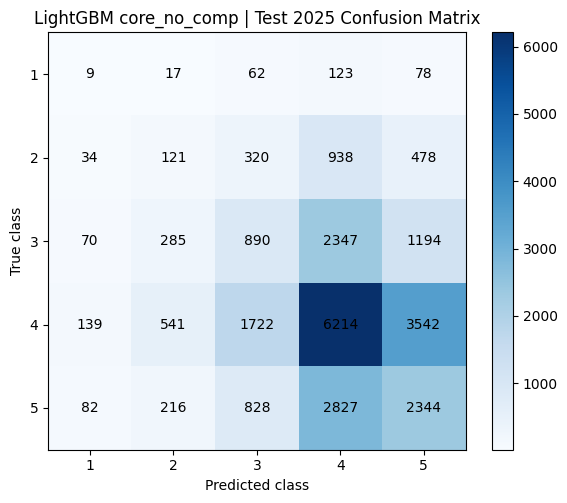

c:\Users\davis\Documents\VCCode Repos\Stack-Overflow-Survey-Analysis\DSBA-6211-Stack-overflow-Survey-Analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:991: RuntimeWarning: invalid value encountered in scalar divide
  k = xp.sum(w_mat * confusion) / xp.sum(w_mat * expected)
c:\Users\davis\Documents\VCCode Repos\Stack-Overflow-Survey-Analysis\DSBA-6211-Stack-overflow-Survey-Analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:991: RuntimeWarning: invalid value encountered in scalar divide
  k = xp.sum(w_mat * confusion) / xp.sum(w_mat * expected)
c:\Users\davis\Documents\VCCode Repos\Stack-Overflow-Survey-Analysis\DSBA-6211-Stack-overflow-Survey-Analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:991: RuntimeWarning: invalid value encountered in scalar divide
  k = xp.sum(w_mat * confusion) / xp.sum(w_mat * expected)
c:\Users\davis\Documents\VCCode Repos\Stack-Overflow-Survey-Analysis\DSBA-6211-Stack-overflow-Survey-Analysis\.venv\Lib\site

Top regions by sample size:


,region,rows,accuracy,macro_f1,weighted_f1,qwk,adjacent_error_rate,far_miss_rate,recall_1,recall_2,recall_3,recall_4,recall_5
3,Europe,12159,0.434493,0.209384,0.383723,0.066037,0.427338,0.138169,0.018692,0.030337,0.062365,0.716425,0.272596
1,Americas,7309,0.352169,0.197423,0.327066,0.049800,0.445889,0.201943,0.021978,0.043810,0.054100,0.369514,0.579514
2,Asia,3797,0.291019,0.202263,0.270598,0.087981,0.471952,0.237029,0.017857,0.111842,0.689252,0.189954,0.177856
4,NaN,786,0.188295,0.156572,0.176618,0.075662,0.353690,0.458015,0.142857,0.246377,0.165605,0.058659,0.436170
5,Oceania,747,0.393574,0.200463,0.367595,0.105993,0.436412,0.170013,0.000000,0.044444,0.043796,0.557065,0.424084
0,Africa,623,0.279294,0.234597,0.289813,0.108594,0.390048,0.330658,0.133333,0.310345,0.416667,0.238095,0.220779


Top countries by sample size:


,country_clean,rows,accuracy,macro_f1,weighted_f1,qwk,adjacent_error_rate,far_miss_rate,recall_1,recall_2,recall_3,recall_4,recall_5
156,United States,4945,0.346208,0.182780,0.304471,0.049013,0.435389,0.218402,0.015625,0.042781,0.022086,0.304367,0.686464
52,Germany,2121,0.459689,0.193196,0.383643,0.069609,0.406412,0.133899,0.000000,0.026738,0.041769,0.802016,0.190244
62,India,1632,0.247549,0.130193,0.150650,0.053916,0.484069,0.268382,0.000000,0.030534,0.908108,0.017045,0.129676
155,United Kingdom,1466,0.416780,0.218923,0.357842,0.074028,0.420873,0.162347,0.066667,0.040650,0.044728,0.714906,0.299383
49,France,1016,0.444882,0.193333,0.371274,0.049876,0.417323,0.137795,0.000000,0.023810,0.016393,0.780287,0.263780
27,Canada,916,0.361354,0.182533,0.337223,0.036457,0.465066,0.173581,0.000000,0.017857,0.035211,0.401302,0.569106
94,NaN,786,0.188295,0.156572,0.176618,0.075662,0.353690,0.458015,0.142857,0.246377,0.165605,0.058659,0.436170
153,Ukraine,708,0.439266,0.178952,0.381601,0.022311,0.453390,0.107345,0.000000,0.000000,0.241667,0.727513,0.043478
118,Poland,652,0.449387,0.187884,0.354434,0.060970,0.415644,0.134969,0.000000,0.032258,0.078014,0.864078,0.097744
103,Netherlands,627,0.483254,0.193192,0.431170,0.023172,0.424242,0.092504,0.000000,0.000000,0.019048,0.719101,0.338346


In [21]:
y_test = test_df[SAT_TARGET]
y_pred = selected_result['test_pred']

conf_df = confusion_frame(y_test, y_pred)
display(conf_df)
plot_confusion(y_test, y_pred, f'{selected_setup} | Test 2025 Confusion Matrix')

region_diag = subgroup_metrics(test_df, y_test, y_pred, ['region']).sort_values('rows', ascending=False)
country_diag = subgroup_metrics(test_df, y_test, y_pred, ['country_clean']).sort_values('rows', ascending=False)

print('Top regions by sample size:')
display(region_diag.head(10))
print('Top countries by sample size:')
display(country_diag.head(15))


In [22]:
binary_diag = (
    test_df
    .assign(
        y_true_binary=test_df[SAT_BINARY],
        y_pred_binary=(selected_result['test_pred'] >= SAT_BINARY_THRESHOLD).astype(int)
    )
)

binary_metrics = {
    'accuracy': accuracy_score(binary_diag['y_true_binary'], binary_diag['y_pred_binary']),
    'macro_f1': f1_score(binary_diag['y_true_binary'], binary_diag['y_pred_binary'], average='macro', zero_division=0),
    'weighted_f1': f1_score(binary_diag['y_true_binary'], binary_diag['y_pred_binary'], average='weighted', zero_division=0),
    'qwk': cohen_kappa_score(binary_diag['y_true_binary'], binary_diag['y_pred_binary'], weights='quadratic')
}

print('Binary diagnostic threshold: >= 4')
display(pd.DataFrame([binary_metrics]).round(4))


Binary diagnostic threshold: >= 4


,accuracy,macro_f1,weighted_f1,qwk
0,0.6583,0.5343,0.6429,0.0738


## Rolling-Origin Check

This is the final stability check for the selected family. I do not want to endlessly retune every model across every possible split, but I do want to see whether the selected model stays competitive as the training window expands over time.


In [19]:
def rolling_origin_satisfaction(clean_frame, model_family='lightgbm', lgb_params=None, catboost_params=None, min_train_year=2015, final_valid_year=2024):
    frame = build_satisfaction_frame(clean_frame)
    rows = []

    for train_years, valid_year, train_df, valid_df in rolling_origin_splits(frame, min_train_year=min_train_year, final_valid_year=final_valid_year):
        if model_family == 'ordered':
            result = fit_ordered_baseline(train_df, valid_df, valid_df, ordered_cat, ordered_num)
        elif model_family == 'catboost':
            result = fit_catboost_multiclass(train_df, valid_df, valid_df, core_cat, core_num, params=catboost_params)
        else:
            result = fit_lgbm_multiclass(train_df, valid_df, valid_df, core_cat, core_num, params=lgb_params)

        rows.append({
            'train_years': ','.join(map(str, train_years)),
            'valid_year': valid_year,
            **result['valid_metrics']
        })

    return pd.DataFrame(rows)


rolling_family = 'catboost' if selected_setup == 'CatBoost core_no_comp' else 'lightgbm'
rolling_main = rolling_origin_satisfaction(
    clean_core,
    model_family=rolling_family,
    lgb_params=lgb_params,
    catboost_params=cat_params,
    min_train_year=2015,
    final_valid_year=2024
)

display(rolling_main)


,train_years,valid_year,accuracy,macro_f1,weighted_f1,qwk,adjacent_error_rate,far_miss_rate,recall_1,recall_2,recall_3,recall_4,recall_5
0,2015,2016,0.292968,0.223537,0.308310,0.074790,0.362732,0.344300,0.087404,0.223120,0.241748,0.249574,0.400822
1,"2015,2016",2017,0.276256,0.206828,0.280189,0.045935,0.381053,0.342691,0.045510,0.219085,0.123451,0.290450,0.429633
2,"2015,2016,2017",2018,0.285286,0.199835,0.296662,0.053607,0.377334,0.337380,0.055290,0.169208,0.095260,0.301451,0.483829
3,"2015,2016,2017,2018",2019,0.311074,0.226236,0.296992,0.113604,0.385826,0.303100,0.050451,0.068487,0.255171,0.315681,0.497623
4,"2015,2016,2017,2018,2019",2020,0.287794,0.183967,0.221722,0.072609,0.435110,0.277096,0.032924,0.038945,0.312621,0.691780,0.079719
5,"2015,2016,2017,2018,2019,2020",2024,0.337119,0.213348,0.329546,0.061402,0.435754,0.227126,0.017857,0.053986,0.157499,0.415470,0.493307


## Next Steps

- keep `LightGBM core_no_comp` as the canonical satisfaction benchmark with the promoted age and career-stage features already in the main spec
- keep compensation as a same-sample sensitivity only, since it helps when observed but changes the modeled population
- keep `undergrad_major` as a monitored side candidate, not a promoted main-spec feature, because the lift is too small and mixed to justify locking it in
- keep later-wave context features like `industry_clean`, `ic_or_pm_clean`, AI fields, and learning fields out of the canonical cross-year model because their support is too uneven across the training window
- frame the final result honestly: the dataset contains some predictive signal for job satisfaction, but even after the final feature audit the model remains modest and should be presented as a limited predictive model rather than a strong one
